### Nạp thư viện

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

### Xử lý dữ liệu

In [ ]:
def load_and_prep_data():
    """Tải và xử lý dữ liệu"""
    df = pd.read_csv('data.csv')
    # Làm sạch và mã hóa cột dạng chữ thành số
    df = df.dropna().drop_duplicates()
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = LabelEncoder().fit_transform(df[col])
    return df


### Huấn luyện và vẽ biểu đồ

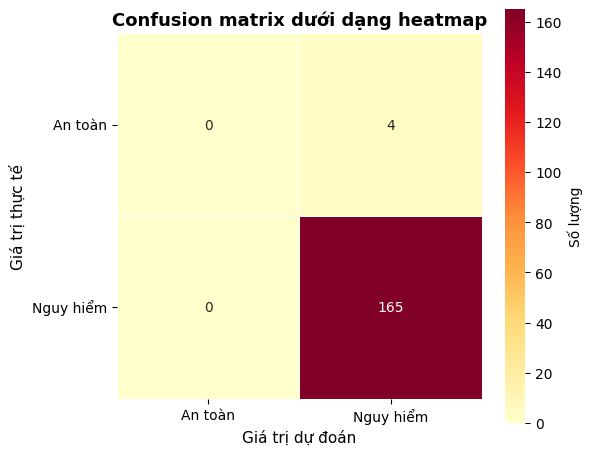

In [8]:
def plot_confusion_heatmap():
    df = load_and_prep_data()
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]
    # Chia dữ liệu train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    # Chuẩn hóa dữ liệu
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    # Huấn luyện mô hình SVM
    svm = SVC(kernel='rbf', gamma='scale', C=1.0, random_state=42)
    svm.fit(X_train_scaled, y_train)
    # Dự đoán
    y_pred = svm.predict(X_test_scaled)
    # Tạo ma trận nhầm lẫn
    cm = confusion_matrix(y_test, y_pred)
    # Vẽ biểu đồ
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm,
                annot=True,         # hiển thị số liệu
                fmt='d',            # định dạng số nguyên
                cmap='YlOrRd',      # màu: vàng → đỏ
                linewidths=0.5,
                square=True,
                cbar_kws={'label': 'Số lượng'})
    plt.title('Confusion matrix dưới dạng heatmap', fontsize=13, fontweight='bold')
    plt.xlabel('Giá trị dự đoán', fontsize=11)
    plt.ylabel('Giá trị thực tế', fontsize=11)
    plt.xticks([0.5, 1.5], ['An toàn', 'Nguy hiểm'])
    plt.yticks([0.5, 1.5], ['An toàn', 'Nguy hiểm'], rotation=0)
    plt.tight_layout()
    plt.show()
if __name__ == "__main__":
    plot_confusion_heatmap()
